### [ IRIS 품종 분류 모델 구현 ]
- 학습종류 : 지도학습 + 분류
- 학습방법 : 인공신경망 + ANN
- 데이터 : iris.csv
- 구현과정
    * 전처리
    * 모델 클래스 선언
    * 데이터셋 클래스 선언
    * 학습진행
    * 검증진행
    * 테스트진행

**[0] 데이터 전처리 관련**
- 모듈 로딩
- 데이터 로딩 및 확인
- 데이터 전처리

In [1]:
import pandas as pd, numpy as np, torch, sys, matplotlib.pyplot as plt, koreanize_matplotlib
sys.path.append('./custom_dataset.py')
from custom_dataset import *
from torch.utils.data import Dataset, TensorDataset
from torch.utils.data import DataLoader

In [2]:
# 데이터 준비 및 확인
df = pd.read_csv('../../[8] 머신러닝/Data/Numbers/iris.csv')
df.head(2)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa


In [3]:
# 전처리
from sklearn.preprocessing import LabelEncoder
lbl = LabelEncoder()
df['target'] = lbl.fit_transform(df['variety'])
display(df.head(1))
print(lbl.classes_)

,sepal.length,sepal.width,petal.length,petal.width,variety,target
0,5.1,3.5,1.4,0.2,Setosa,0


['Setosa' 'Versicolor' 'Virginica']


**[1]학습준비**
- 클래스 준비 : 모델, 데이터셋
- 학습 설정 : 학습 횟수, 배치 크기, 러닝 레이트, 이터레이션 개수
- 데이터셋 준비 : 학습용, 테스트용, 검증용

In [4]:
# [1-1] 데이터셋 준비 : 학습 | 검증 | 테스트
from sklearn.model_selection import train_test_split

# 피쳐 타겟 분리
feature = df[df.columns[:-2]]
target = df[df.columns[-1]]
print(feature.shape, feature.columns, '\n', target.shape, target.dtype)

(150, 4) Index(['sepal.length', 'sepal.width', 'petal.length', 'petal.width'], dtype='str') 
 (150,) int64


In [5]:
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42, stratify=target)
print(f'{x_train.shape}, {y_train.shape}, {y_train.value_counts().to_list()}')
print(f'{x_test.shape}, {y_test.shape}, {y_test.value_counts().to_list()}')

(120, 4), (120,), [40, 40, 40]
(30, 4), (30,), [10, 10, 10]


In [6]:
# 학습용 : 검증용 = 80 :20
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
print(f'{x_train.shape}, {y_train.shape}, {y_train.value_counts().to_list()}')
print(f'{x_valid.shape}, {y_valid.shape}, {y_test.value_counts().to_list()}')

(96, 4), (96,), [32, 32, 32]
(24, 4), (24,), [10, 10, 10]


In [7]:
# 학습 관련 설정
# => 학습 횟수 : epoch
epochs = 1000

# => 학습량 : 1번 학습 후 W,B 업데이트
bs = 32

# => 반복횟수 : W,B 업데이트 횟수 -> 학습중 즉, 학습용 데이터 셋
iters = x_train.shape[0]//bs

# => W,B 값 보정 정도 : 러닝레잍,. 스텝사이즈. 0.1 ~ 0.001
LR = 0.001

In [14]:
import sys 
sys.path.append(r'D:\KDT\VS_KDT_14\[9]_DL\DAY03')
from custom_dataset import * 

import torch.nn as nn
from torch.optim import Adam 
from torch.utils.data import DataLoader


## => 모델 인스턴스 생성
model = IrisClassifier()

## => 모델 최적화 인스턴스 생성
adam = Adam(model.parameters(), lr=LR)

## => 손실함수 인스턴스 생성
criterion = nn.CrossEntropyLoss()

## => 학습용|검증용|테스트용 데이터셋 인스턴스 생성
trainDS = IrisDataset(x_train, y_train.to_frame())
testDS  = IrisDataset(x_test,  y_test.to_frame())
validDS = IrisDataset(x_valid, y_valid.to_frame())

trainDL = DataLoader(trainDS, batch_size=bs, shuffle=True, drop_last=True)
testDL  = DataLoader(testDS,  batch_size=x_test.shape[0])
validDL = DataLoader(validDS, batch_size=x_valid.shape[0])

**[2] 학습 진행**
- epoch 단위 loss 저장 : 배치단위 loss 모두 저장 후 평균계산
- epoch 증가 될수록 loss 감소되어야 함 
- 학습용과 검증용 비교 진행 => 과대적합 체크 및 학습 중단 고려

In [15]:
## 성능지표
from sklearn.metrics import f1_score

## 에포크 단위 loss 저장용 변수 
lossEpoch, scoreEpoch = {'Train':[], 'Valid':[]},   {'Train':[], 'Valid':[]}

for epo in range(epochs+1):
    ## loss, score 저장 변수
    lossDict  = {'Train':[], 'Valid':[]}
    scoreDict = {'Train':[], 'Valid':[]}

    ## -------------------------------
    ## 모델 학습 모드 설정
    ## -------------------------------
    model.train()

    ## 배치 단위 학습 진행
    for data, target in trainDL:

        ## 순전파 진행 => 가중치 합계
        pre_target = model(data)

        ## 역전파 업데이트 위한 grad 초기화 
        ## => 모델의 모든 층의 W,b에 업데이트할 값 저장 속성 grad
        ## => 초기화 하지 않으면 누적 
        adam.zero_grad()

        ## 손실 계산 -> 주의: 손실함수마다 원하는 자료형, 형태가 다름!
        ## -> CrossEntropyLoss : 정답 타겟 - 1D, Long
        loss = criterion(pre_target, target.reshape(-1).long())

        ## 역전파 진행=> 새로운 W,b 값 계산 후 grad에 저장 
        loss.backward() 

        ## W,b 업데이트 
        adam.step()
    
        ## F1 점수계산 
        preNP   = pre_target.argmax(dim=1).detach().squeeze().numpy()
        labelNP = target.detach().squeeze().numpy()
        score   = f1_score(labelNP, preNP, average='macro')

        ## 배치단위 손실 저장
        lossDict['Train'].append(loss.item())
        scoreDict['Train'].append(score)

    # -------------------------------
    # 모델 검증 모드 설정
    # -------------------------------
    ## 역전파, 기울기계산 등 비활성화
    model.eval()

    ## W,b 텐서의 requires_grad=False
    with torch.no_grad():
        for data, target in validDL:
            # 예측
            pre_target = model(data)

            # 손실
            loss = criterion(pre_target, target.reshape(-1).long())

            # F1 점수
            preNP   = pre_target.argmax(dim=1).detach().squeeze().numpy()
            labelNP = target.detach().squeeze().numpy()
            score   = f1_score(labelNP, preNP, average='macro')

            # 손실 및 F1점수 저장 
            lossDict['Valid'].append(loss.item())
            scoreDict['Valid'].append(score)

    ## 에포크 단위 손실 평균값 저장 및 출력
    if not epo%10:
        for key_name in ['Train', 'Valid']:
            loss  = sum(lossDict[key_name])/len(lossDict[key_name])
            score = sum(scoreDict[key_name])/len(scoreDict[key_name])
            lossEpoch[key_name].append(loss)
            scoreEpoch[key_name].append(score)

        print(f"[EPOCH-{epo:04}] TRAIN LOSS :{lossEpoch['Train'][-1]:.7f}  SCORE :{scoreEpoch['Train'][-1]:.7f}", end=' ')
        print(f"   VALID LOSS :{lossEpoch['Valid'][-1]:.7f}  SCORE :{scoreEpoch['Valid'][-1]:.7f}")


        

[EPOCH-0000] TRAIN LOSS :1.3879602  SCORE :0.1654895    VALID LOSS :1.3797392  SCORE :0.1666667
[EPOCH-0010] TRAIN LOSS :1.2082328  SCORE :0.1662341    VALID LOSS :1.2047356  SCORE :0.1666667
[EPOCH-0020] TRAIN LOSS :1.1173700  SCORE :0.1654895    VALID LOSS :1.1157616  SCORE :0.1666667
[EPOCH-0030] TRAIN LOSS :1.0612353  SCORE :0.5275733    VALID LOSS :1.0600437  SCORE :0.5555556
[EPOCH-0040] TRAIN LOSS :1.0145946  SCORE :0.5564893    VALID LOSS :1.0121068  SCORE :0.5555556
[EPOCH-0050] TRAIN LOSS :0.9671048  SCORE :0.5546062    VALID LOSS :0.9624149  SCORE :0.5555556
[EPOCH-0060] TRAIN LOSS :0.9224046  SCORE :0.5555556    VALID LOSS :0.9148817  SCORE :0.5555556
[EPOCH-0070] TRAIN LOSS :0.8711654  SCORE :0.4457216    VALID LOSS :0.8602249  SCORE :0.4666667
[EPOCH-0080] TRAIN LOSS :0.8101337  SCORE :0.5548360    VALID LOSS :0.8018931  SCORE :0.5555556
[EPOCH-0090] TRAIN LOSS :0.7592081  SCORE :0.5520015    VALID LOSS :0.7513761  SCORE :0.5555556
[EPOCH-0100] TRAIN LOSS :0.7160443  SCOR

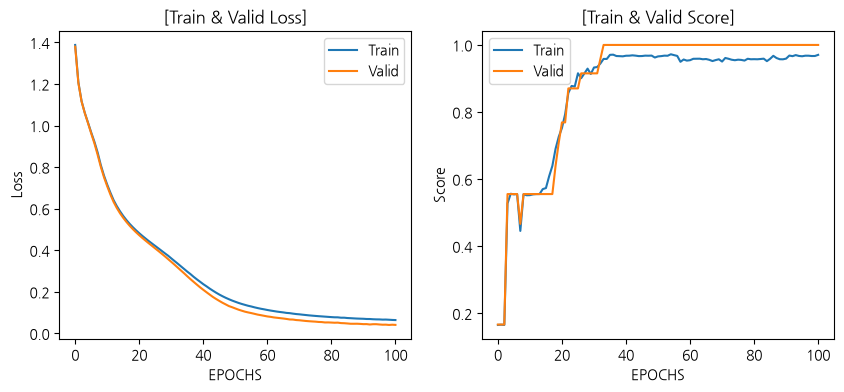

In [16]:
## ======================================================
## 시각화
## ======================================================
fig, axes = plt.subplots(1, 2, figsize=(10,4))

for ax, title, epochList in zip(axes, ['Loss', 'Score'], [lossEpoch, scoreEpoch]):

    ax.plot(epochList['Train'], label = 'Train')
    ax.plot(epochList['Valid'], label = 'Valid')

    ax.set_title(f"[Train & Valid {title}]")
    ax.set_xlabel("EPOCHS")
    ax.set_ylabel(f"{title}")
    ax.legend()
plt.show()